In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Mall_Customers.csv", delimiter=',')

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
# Exploracao de dados

In [4]:
df.isnull().values.any() #Indica que existe(m) valor(es) nulo(s) no dataframe

False

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df['Gender'].unique() # Verificando formas 'unicas' que podem ter sido inseridas na variável Gender

array(['Male', 'Female'], dtype=object)

In [7]:
# Concluimos após esta etapa de exploracao que nao existem valores nulos em nosso df e também o gênero foi empregado apenas das 2 maneiras padroes 

In [8]:
# Tratamento de dados

In [10]:
# Excluindo colunas com valores categóricos 

    # Esta etapa é obrigatoria, pois o k-means nao trabalha com dados categoricos

    # A coluna 'CustomerID' serve como identificacao dos compradores, logo ela também será tratada como variável categórica

df.drop(columns=['CustomerID', 'Gender'], inplace=True)

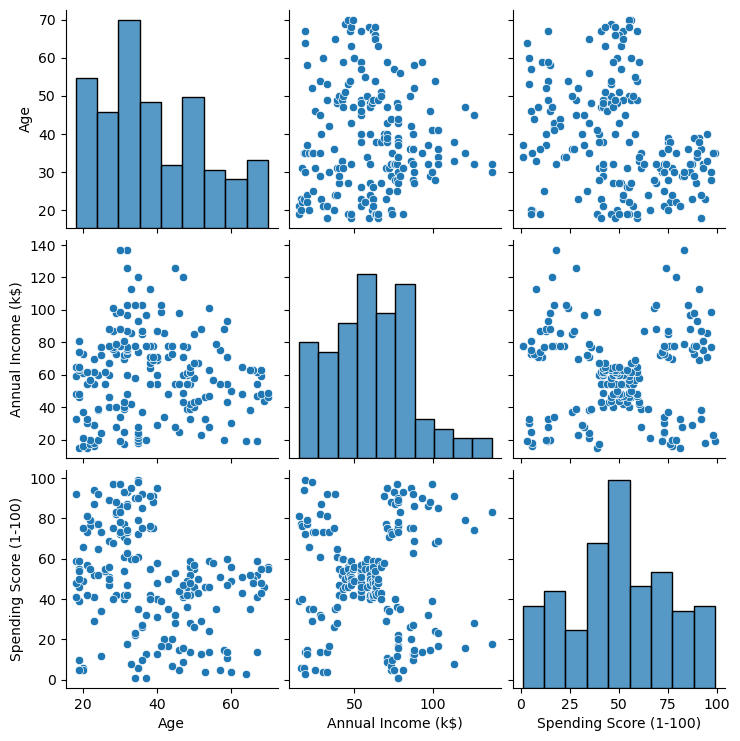

In [11]:
sns.pairplot(df)

In [12]:
# Padronizacao (ou normalização) dos dados

    # Etapa necessaria para utilizar o K-means

df_padronizado = df.copy()

In [13]:
colunas_padronizar = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Iniciar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
df_padronizado[colunas_padronizar] = scaler.fit_transform(df[colunas_padronizar])

In [14]:
df_padronizado

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [59]:
kmeans_especie = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_especie.fit(df_padronizado)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KMeans(n_clusters=3, n_init=10, random_state=42)

In [60]:
# Ao analisar o pairplot, creio que 3 clusters sao o ideal para a divisao dos dados

In [61]:
centroides_padronizado = kmeans_especie.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_padronizado)
centroides_originais

array([[25.83823529, 42.75      , 53.64705882],
       [32.85365854, 87.34146341, 79.97560976],
       [51.27472527, 61.8021978 , 34.20879121]])

In [62]:
labels = kmeans_especie.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0,
       0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       1, 1])

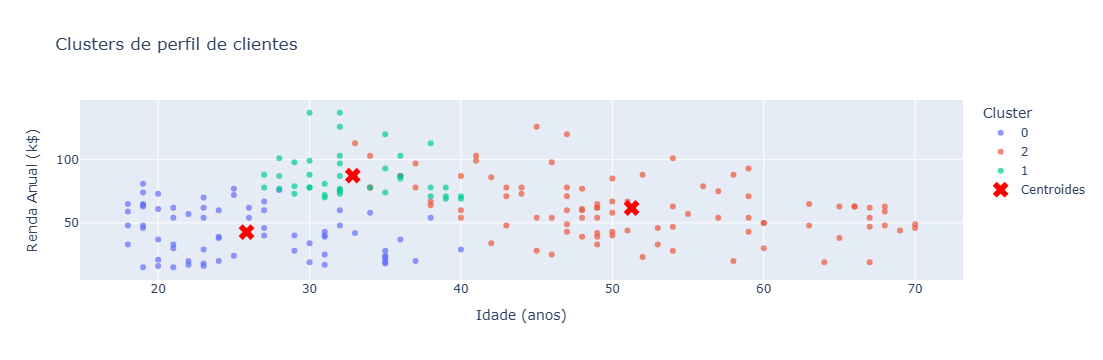

In [63]:
df_clusters = pd.DataFrame({
	'Age':df['Age'],
	'Annual Income (k$)': df['Annual Income (k$)'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='Age', y='Annual Income (k$)', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de perfil de clientes')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='Idade (anos)', yaxis_title='Renda Anual (k$)',
		legend_title='Cluster')
fig.show()

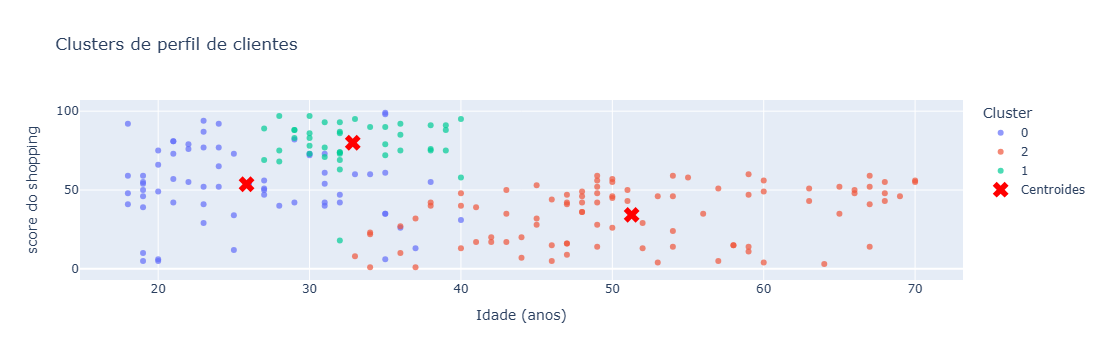

In [64]:
df_clusters = pd.DataFrame({
	'Age':df['Age'],
	'Spending Score (1-100)': df['Spending Score (1-100)'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='Age', y='Spending Score (1-100)', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de perfil de clientes')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 2],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='Idade (anos)', yaxis_title='score do shopping',
		legend_title='Cluster')
fig.show()

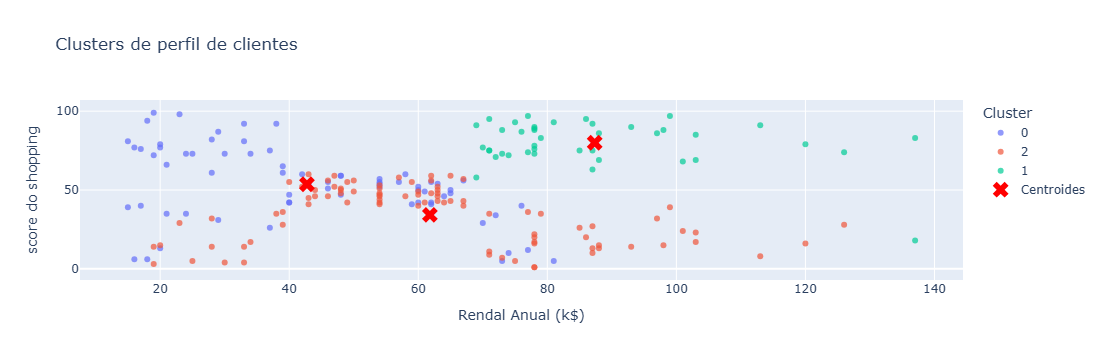

In [65]:
df_clusters = pd.DataFrame({
	'Annual Income (k$)':df['Annual Income (k$)'],
	'Spending Score (1-100)': df['Spending Score (1-100)'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de perfil de clientes')

fig.add_scatter(x=centroides_originais[:, 1], y=centroides_originais[:, 2],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='Rendal Anual (k$)', yaxis_title='score do shopping',
		legend_title='Cluster')
fig.show()

In [ ]:
# Notamos pela divisao dos clusters que:

# a renda anual mais elevada tente a vir para os clientes que estao mais presentes na fase de maturidade, ou seja, entre 30 e 50 anos em sua maioria

# os maiores niveis de score estao para os clientes que possuem ate 40 anos de idade, pelo fato de que terao tendo habil para fazer gastos e saná-los

# notamos que o score nao tem forte relacao com a renda anual